# Benchmark v5 — GPU — FreeSolv — scaffold split, seed 0

**Task:** Predict experimental hydration free energy in kcal/mol
**Size:** ~642 molecules
**Metric:** RMSE ↓, MAE ↓, R² ↑

**Scaffold split**, seed **0** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_0/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "freesolv"
TASK_TYPE = "regression"
OUT_CHANNELS = 1
BATCH_SIZE = 32
GNN_EPOCHS = 120
LSTM_EPOCHS = 120
TOX21_TABULAR = False

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 20
print(f"GPU HPO tier: standard — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 0

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: standard — 20 trials, 80 epochs/trial, batch=32
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold
SPLIT_SEED=0  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("freesolv", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "freesolv")
print(f"Molecules : {len(smiles)}")
print(f"Target    : [{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.2f} kcal/mol")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'freesolv' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/freesolv.csv
INFO | [freesolv] 642 / 642 valid molecules


Molecules : 642
Target    : [-25.47, 3.43]  mean=-3.80 kcal/mol
After bond filter: 639 molecules


### Representations & scaffold split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


INFO | Loaded 642 / 642 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/freesolv_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/splits/freesolv_scaffold_splits.pkl


3D graphs loaded: 642 / 639 (valid_idx mapping)
{'n_total': 639, 'n_train': 511, 'n_val': 64, 'n_test': 64, 'n_scaffolds_total': 63, 'n_scaffolds_train': 5, 'n_scaffolds_val': 10, 'n_scaffolds_test': 48}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 2D — starting trial 1/20 (layers=5, hidden=192)


→ GIN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=10.6762 | val={'RMSE': 6.61453391627849, 'MAE': 4.482901042327285, 'R2': -0.23040543953060033}
INFO | HPO epoch   5/80 | loss=4.9954 | val={'RMSE': 3.977714751877857, 'MAE': 2.9143223757855594, 'R2': 0.5550440494973616}
INFO | HPO epoch  10/80 | loss=2.3830 | val={'RMSE': 3.074249339961423, 'MAE': 2.0609742475207895, 'R2': 0.7342165563774397}
INFO | HPO epoch  15/80 | loss=2.2568 | val={'RMSE': 2.565098582427273, 'MAE': 1.7606229642406106, 'R2': 0.8149633025686818}
INFO | HPO epoch  20/80 | loss=1.8413 | val={'RMSE': 2.757255910810604, 'MAE': 2.135314855724573, 'R2': 0.786201871164498}
INFO | HPO epoch  25/80 | loss=1.2051 | val={'RMSE': 2.6575368856572066, 'MAE': 1.7785110783297569, 'R2': 0.8013866899632612}
INFO | HPO epoch  30/80 | loss=1.2363 | val={'RMSE': 3.3181027137241506, 'MAE': 2.078649698756635, 'R2': 0.690379720337897}
INFO | Early stop at epoch 34 (patience=15)
INFO | GIN 2D HPO — trial 1/20 finished | val=2.398288 | best=2.398288
INFO | GIN 

   scaffold test: {'RMSE': 2.4722633575393016, 'MAE': 1.6976290987804532, 'R2': 0.5494788301669293}


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | DMPNN 2D — starting trial 1/20 (layers=5, hidden=192)


→ D-MPNN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=16.2349 | val={'RMSE': 6.189251289709846, 'MAE': 4.548473177477717, 'R2': -0.07727350518658138}
INFO | HPO epoch   5/80 | loss=7.7787 | val={'RMSE': 5.841344286028742, 'MAE': 3.9191862707957625, 'R2': 0.040432886456915895}
INFO | HPO epoch  10/80 | loss=4.3259 | val={'RMSE': 3.989721538879567, 'MAE': 3.1236870351131074, 'R2': 0.5523537839310424}
INFO | HPO epoch  15/80 | loss=2.4283 | val={'RMSE': 3.0044076948841587, 'MAE': 2.448834614828229, 'R2': 0.7461556634796767}
INFO | HPO epoch  20/80 | loss=1.9605 | val={'RMSE': 2.751834986398694, 'MAE': 2.318550401367247, 'R2': 0.7870417236983386}
INFO | HPO epoch  25/80 | loss=1.5802 | val={'RMSE': 2.9799590471996247, 'MAE': 2.5393246449530125, 'R2': 0.7502702177032556}
INFO | HPO epoch  30/80 | loss=1.2513 | val={'RMSE': 2.861244618368039, 'MAE': 2.2705007307231426, 'R2': 0.7697711602833291}
INFO | HPO epoch  35/80 | loss=1.3912 | val={'RMSE': 3.181534854195663, 'MAE': 2.3136951876804233, 'R2': 0.71534218079929

   scaffold test: {'RMSE': 2.397277515821547, 'MAE': 1.825078044552356, 'R2': 0.5763937459574817}


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/20 (layers=5, hidden=192)


→ GIN (3D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=14.0321 | val={'RMSE': 4.489556189277025, 'MAE': 3.1358414264395833, 'R2': -0.058895547762002565}
INFO | HPO epoch   5/80 | loss=4.7161 | val={'RMSE': 2.519142515940328, 'MAE': 1.9543361086398363, 'R2': 0.6666106097411173}
INFO | HPO epoch  10/80 | loss=2.3420 | val={'RMSE': 1.845803667402134, 'MAE': 1.403816195204854, 'R2': 0.8210147228148572}
INFO | HPO epoch  15/80 | loss=2.6426 | val={'RMSE': 1.4428468633445257, 'MAE': 1.148701868019998, 'R2': 0.8906328792392506}
INFO | HPO epoch  20/80 | loss=1.8687 | val={'RMSE': 1.4697286212215661, 'MAE': 0.985347586683929, 'R2': 0.8865196666693054}
INFO | HPO epoch  25/80 | loss=1.5163 | val={'RMSE': 1.3234346278547302, 'MAE': 0.9504388140048832, 'R2': 0.9079865558185098}
INFO | HPO epoch  30/80 | loss=1.7733 | val={'RMSE': 1.6004589651947956, 'MAE': 1.149767859838903, 'R2': 0.8654339864987749}
INFO | HPO epoch  35/80 | loss=1.3849 | val={'RMSE': 1.5602085777162764, 'MAE': 1.225520743522793, 'R2': 0.87211735152597

   scaffold test: {'RMSE': 0.9637903948502048, 'MAE': 0.5589633808704093, 'R2': 0.9156047898813163}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | SchNet — starting trial 1/20


→ SchNet (3D coords) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=11.9017 | val={'RMSE': 3.642005966898721, 'MAE': 2.6502141242381185, 'R2': 0.3031687712288238}
INFO | HPO epoch   5/80 | loss=4.6665 | val={'RMSE': 2.4073139179481275, 'MAE': 1.8923737751320004, 'R2': 0.6955529620788719}
INFO | HPO epoch  10/80 | loss=2.8400 | val={'RMSE': 2.1011382448800426, 'MAE': 1.5323834982700646, 'R2': 0.7680707330970002}
INFO | HPO epoch  15/80 | loss=2.0264 | val={'RMSE': 1.9560564012677901, 'MAE': 1.4029034418053925, 'R2': 0.798993988610541}
INFO | HPO epoch  20/80 | loss=1.5249 | val={'RMSE': 1.80049830516524, 'MAE': 1.257430999306962, 'R2': 0.8296933001746598}
INFO | HPO epoch  25/80 | loss=1.3122 | val={'RMSE': 1.7082650883647794, 'MAE': 1.2132047245977446, 'R2': 0.8466948197045265}
INFO | HPO epoch  30/80 | loss=1.0827 | val={'RMSE': 1.5429859384117994, 'MAE': 0.9654962499625981, 'R2': 0.8749250793440564}
INFO | HPO epoch  35/80 | loss=0.9738 | val={'RMSE': 1.485300397929853, 'MAE': 0.9401725484058261, 'R2': 0.884102279474970

   scaffold test: {'RMSE': 0.9250562218649532, 'MAE': 0.5929184457054362, 'R2': 0.9222520640467606}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/20


→ SMILES LSTM (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=20.9509 | val={'RMSE': 8.572283295254925, 'MAE': 6.630936645786278, 'R2': -1.0665350579337334}
INFO | HPO epoch   5/80 | loss=12.6677 | val={'RMSE': 7.320375560480268, 'MAE': 4.985515994951129, 'R2': -0.5070111723110864}
INFO | HPO epoch  10/80 | loss=7.1270 | val={'RMSE': 5.8884181127521265, 'MAE': 4.205989590846002, 'R2': 0.024904781189650116}
INFO | HPO epoch  15/80 | loss=5.7289 | val={'RMSE': 5.514770778948199, 'MAE': 3.9952196730300784, 'R2': 0.14472716437770006}
INFO | HPO epoch  20/80 | loss=4.5775 | val={'RMSE': 4.97512860875393, 'MAE': 3.5855294736102223, 'R2': 0.30392125778133583}
INFO | HPO epoch  25/80 | loss=3.9279 | val={'RMSE': 4.659334642976423, 'MAE': 3.1747921685455367, 'R2': 0.38948329153161043}
INFO | HPO epoch  30/80 | loss=3.8890 | val={'RMSE': 4.5275947099282945, 'MAE': 3.0058145211078227, 'R2': 0.42351921686128835}
INFO | HPO epoch  35/80 | loss=3.1270 | val={'RMSE': 4.4079963554104005, 'MAE': 2.9136674415203743, 'R2': 0.453572936

   scaffold test: {'RMSE': 2.1203593051035687, 'MAE': 1.531836399808526, 'R2': 0.668605985608938}


### Finalize GPU + merge


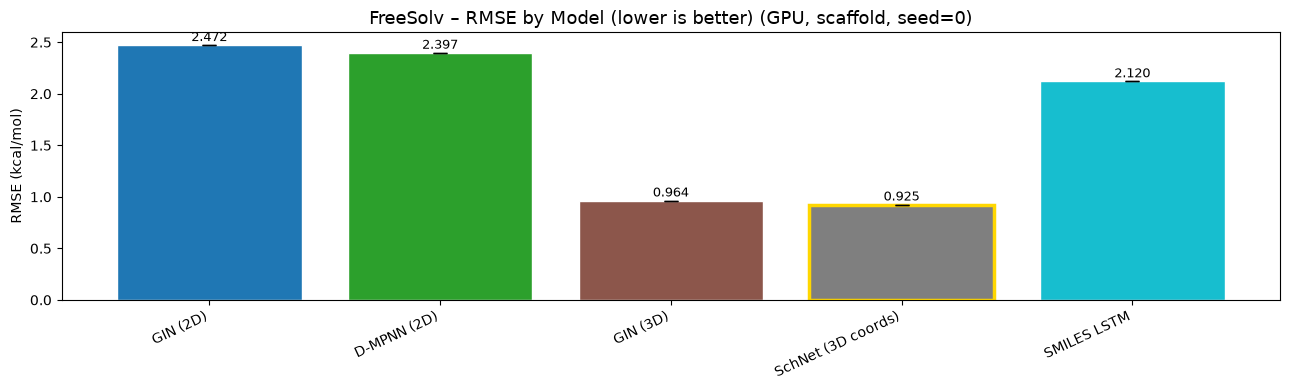

=== FREESOLV Results (5/12 models) ===
                               RMSE              MAE               R2
Model                                                                
GIN (2D)            2.4723 ± 0.0000  1.6976 ± 0.0000  0.5495 ± 0.0000
D-MPNN (2D)         2.3973 ± 0.0000  1.8251 ± 0.0000  0.5764 ± 0.0000
GIN (3D)            0.9638 ± 0.0000  0.5590 ± 0.0000  0.9156 ± 0.0000
SchNet (3D coords)  0.9251 ± 0.0000  0.5929 ± 0.0000  0.9223 ± 0.0000
SMILES LSTM         2.1204 ± 0.0000  1.5318 ± 0.0000  0.6686 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/freesolv_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/freesolv_rmse_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmar

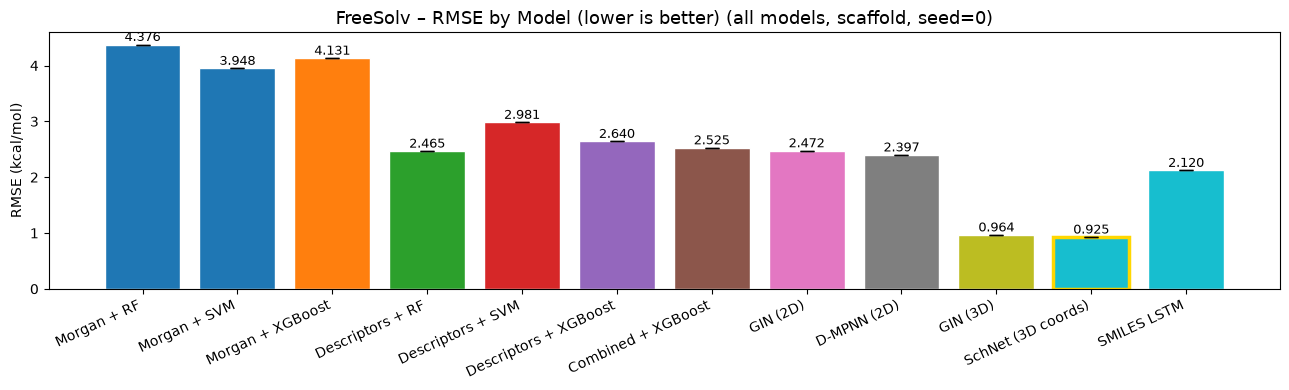

=== FREESOLV Results (12/12 models) ===
                                  RMSE              MAE                R2
Model                                                                    
Morgan + RF            4.3764 ± 0.0000  3.4350 ± 0.0000  -0.4117 ± 0.0000
Morgan + SVM           3.9479 ± 0.0000  2.9590 ± 0.0000  -0.1488 ± 0.0000
Morgan + XGBoost       4.1310 ± 0.0000  3.2197 ± 0.0000  -0.2579 ± 0.0000
Descriptors + RF       2.4652 ± 0.0000  1.8517 ± 0.0000   0.5520 ± 0.0000
Descriptors + SVM      2.9811 ± 0.0000  1.9733 ± 0.0000   0.3449 ± 0.0000
Descriptors + XGBoost  2.6400 ± 0.0000  1.8697 ± 0.0000   0.4863 ± 0.0000
Combined + XGBoost     2.5247 ± 0.0000  1.8887 ± 0.0000   0.5302 ± 0.0000
GIN (2D)               2.4723 ± 0.0000  1.6976 ± 0.0000   0.5495 ± 0.0000
D-MPNN (2D)            2.3973 ± 0.0000  1.8251 ± 0.0000   0.5764 ± 0.0000
GIN (3D)               0.9638 ± 0.0000  0.5590 ± 0.0000   0.9156 ± 0.0000
SchNet (3D coords)     0.9251 ± 0.0000  0.5929 ± 0.0000   0.9223 ± 0.000

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"FreeSolv – RMSE by Model (lower is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (kcal/mol)", minimize=True)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"FreeSolv – RMSE by Model (lower is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (kcal/mol)", minimize=True)
else:
    print("Run CPU notebook first for combined results.")
